In [1]:
# =============================================================================
# Time Series Model Progression
# AR  →  MA  →  ARMA  →  ARIMA  →  SARIMA  →  Auto ARIMA
# Dataset : AirPassengers (1949-1960, Monthly International Airline Passengers)
# =============================================================================
#
# Learning Flow:
#   SECTION 0  : Data Load & Overview
#   SECTION 1  : AR   - AutoRegressive Model          (stationary subset)
#   SECTION 2  : MA   - Moving Average Model          (stationary subset)
#   SECTION 3  : ARMA - AR + MA combined              (stationary subset)
#   SECTION 4  : ARIMA- ARMA + Differencing           (handles trend)
#   SECTION 5  : SARIMA- ARIMA + Seasonal             (handles trend + seasonality)
#   SECTION 6  : Auto ARIMA - automated order selection
#   SECTION 7  : Model Comparison Summary
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm

# ─────────────────────────────────────────────────────────────────────────────
# AirPassengers data (inline — identical to the R/statsmodels dataset)
# Source: Box & Jenkins (1976). Monthly totals of international airline
#         passengers, 1949-1960.
# When running locally, you can replace this block with:
#   raw = get_rdataset("AirPassengers", "datasets").data
# ─────────────────────────────────────────────────────────────────────────────
_AP_VALUES = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
]



In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared Utilities
# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics(actual, predicted):
    """MAE / RMSE / MAPE on original-scale values."""
    a = np.array(actual);  p = np.array(predicted)
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, mape

def adf_test(series, label=""):
    res = adfuller(series.dropna(), autolag="AIC")
    status = "Stationary ✓" if res[1] < 0.05 else "Non-stationary ✗"
    print(f"  ADF [{label}]  p={res[1]:.4f}  →  {status}")
    return res[1]

def plot_forecast(ax, train, test, fc_vals,
                  ci_lo=None, ci_hi=None,
                  title="", fc_color="#F96167"):
    ax.plot(train.index, train.values,
            color="#1C7293", lw=1.8, label="Train")
    ax.plot(test.index,  test.values,
            color="#028090", lw=1.8, ls="--", label="Actual (Test)")
    ax.plot(test.index,  fc_vals,
            color=fc_color,  lw=2.0, label="Forecast")
    if ci_lo is not None:
        ax.fill_between(test.index, ci_lo, ci_hi,
                        color=fc_color, alpha=0.18, label="95% CI")
    ax.axvline(test.index[0], color="gray", ls=":", lw=1.0)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Passengers")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)




  SECTION 0 : Data Load & Overview
  Full series  : 144 months  (1949-01 ~ 1960-12)
  Train (raw)  : 108 months  (1949-01 ~ 1957-12)
  Test  (raw)  : 36 months  (1958-01 ~ 1960-12)
  Stat series  : log + 1st diff of train → 107 obs
  ADF [Original train]  p=0.9943  →  Non-stationary ✗
  ADF [Log-transformed]  p=0.7542  →  Non-stationary ✗
  ADF [Log + 1st diff]  p=0.0501  →  Non-stationary ✗


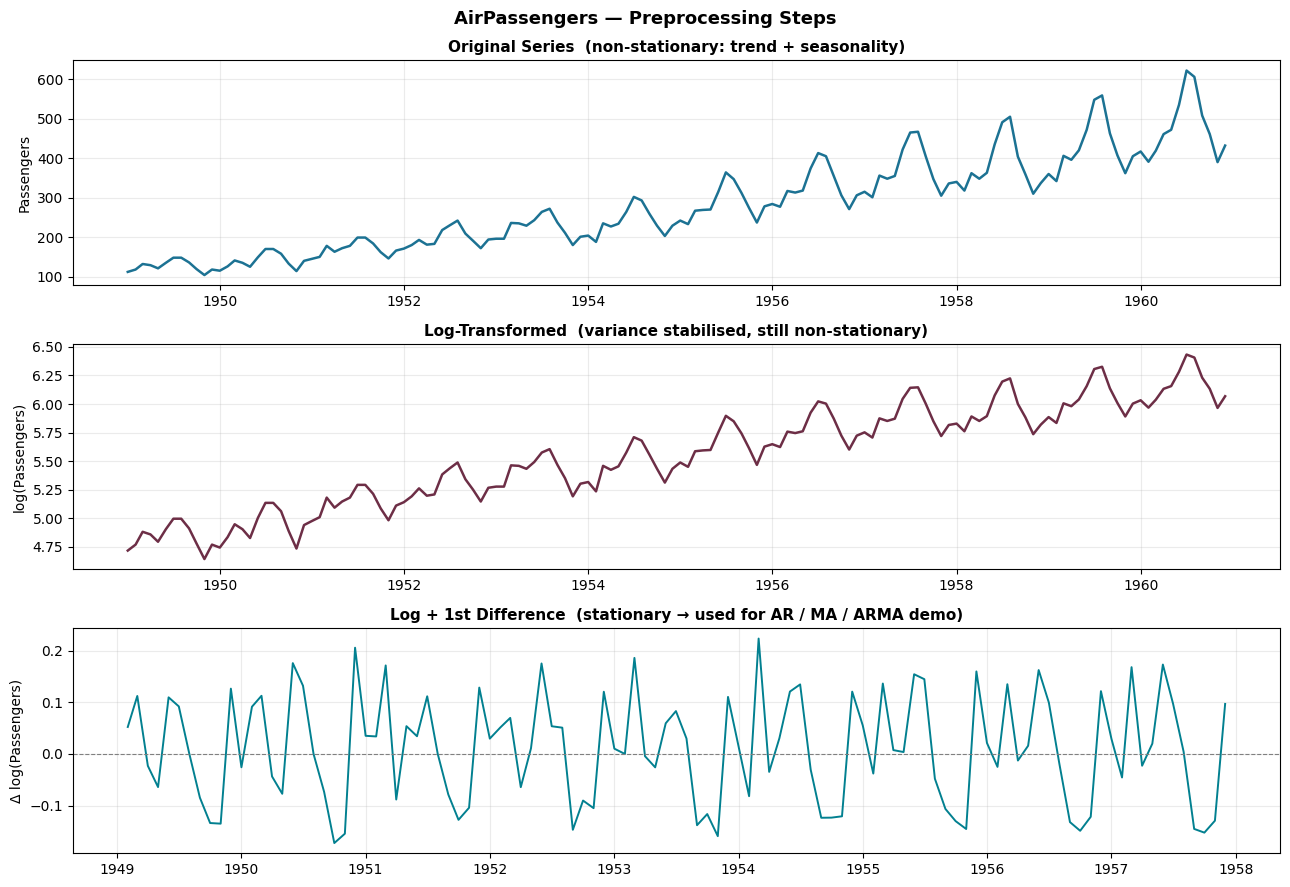

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 : Data Load & Overview
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 0 : Data Load & Overview")
print("=" * 65)

data = pd.Series(
    _AP_VALUES,
    index=pd.date_range(start="1949-01", periods=144, freq="MS"),
    name="passengers"
)
log_data = np.log(data)          # log-transform: stabilise multiplicative variance

# ── Train / Test split ──────────────────────────────────────────────────────
#   Train : 1949-01 ~ 1957-12   (108 months)
#   Test  : 1958-01 ~ 1960-12   ( 36 months)
train_raw = data[:"1957-12"];     test_raw = data["1958-01":]
train_log = log_data[:"1957-12"]; test_log = log_data["1958-01":]

# ── For AR/MA/ARMA we need a *stationary* series ────────────────────────────
# Use log + 1st-difference of the training portion only
stat_series = train_log.diff(1).dropna()   # stationary, trend removed
# Split stationary series for AR/MA/ARMA demo (last 24 pts = test window)
stat_train = stat_series[:-24]
stat_test  = stat_series[-24:]

print(f"  Full series  : {len(data)} months  (1949-01 ~ 1960-12)")
print(f"  Train (raw)  : {len(train_raw)} months  (1949-01 ~ 1957-12)")
print(f"  Test  (raw)  : {len(test_raw)} months  (1958-01 ~ 1960-12)")
print(f"  Stat series  : log + 1st diff of train → {len(stat_series)} obs")

# ── ADF confirmation ─────────────────────────────────────────────────────────
adf_test(train_raw,   "Original train")
adf_test(train_log,   "Log-transformed")
adf_test(stat_series, "Log + 1st diff")

# ── Overview figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].plot(data.index, data.values, color="#1C7293", lw=1.8)
axes[0].set_title("Original Series  (non-stationary: trend + seasonality)",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Passengers"); axes[0].grid(True, alpha=0.25)

axes[1].plot(log_data.index, log_data.values, color="#6D2E46", lw=1.8)
axes[1].set_title("Log-Transformed  (variance stabilised, still non-stationary)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("log(Passengers)"); axes[1].grid(True, alpha=0.25)

axes[2].plot(stat_series.index, stat_series.values, color="#028090", lw=1.4)
axes[2].axhline(0, color="gray", ls="--", lw=0.8)
axes[2].set_title("Log + 1st Difference  (stationary → used for AR / MA / ARMA demo)",
                  fontsize=11, fontweight="bold")
axes[2].set_ylabel("Δ log(Passengers)"); axes[2].grid(True, alpha=0.25)

plt.suptitle("AirPassengers — Preprocessing Steps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 1 : AR — AutoRegressive Model

  Concept:
    Yₜ = c + φ₁Yₜ₋₁ + φ₂Yₜ₋₂ + ... + φₚYₜ₋ₚ + εₜ
    → Current value is a LINEAR COMBINATION of its own past values.
    → Order p : how many past lags to include.
    → Requires STATIONARY series.

  PACF plot: choose p where PACF cuts off (drops inside confidence band).



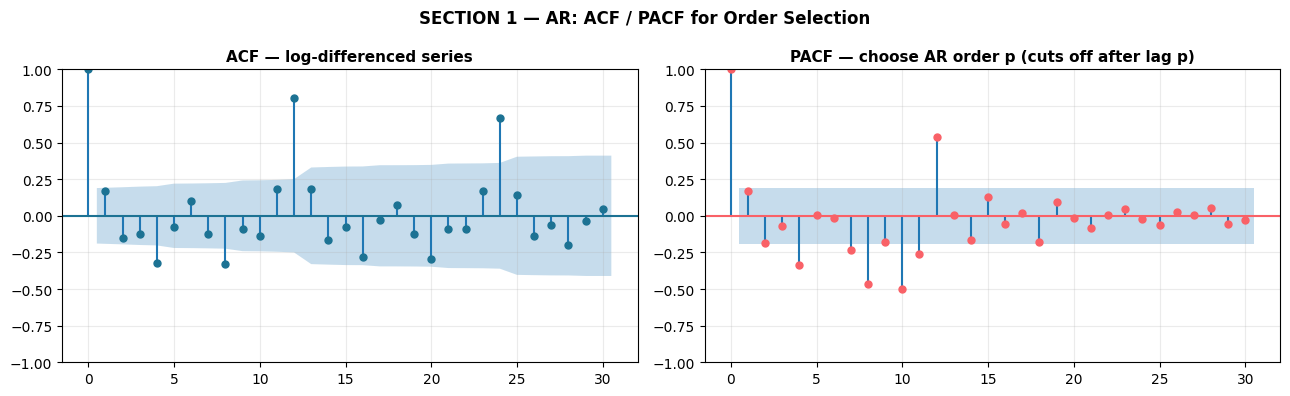

  AR(2) fitted on stationary (log-diff) series
  MAE=0.08806  RMSE=0.10610  MAPE=105.02%
  Note: metrics are in log-diff scale (small absolute values are normal)


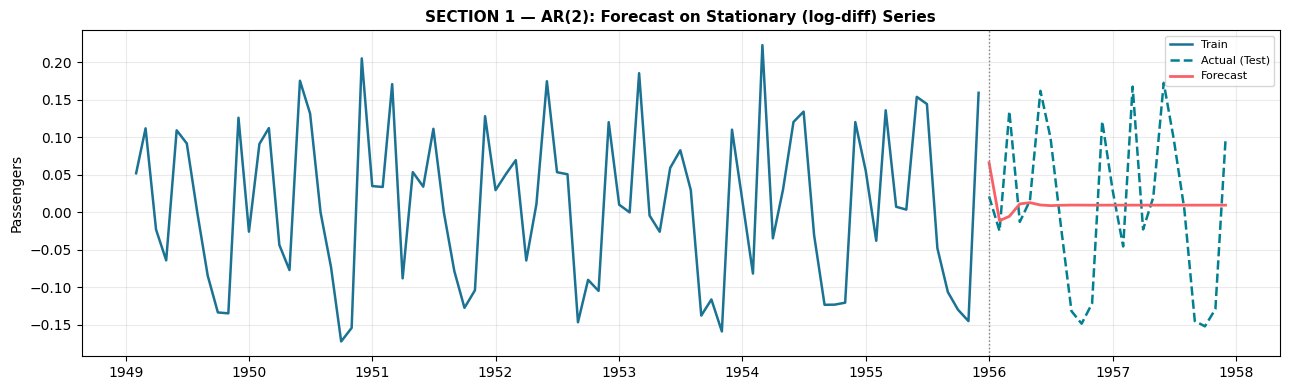

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 : AR (AutoRegressive Model)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 1 : AR — AutoRegressive Model")
print("=" * 65)
print("""
  Concept:
    Yₜ = c + φ₁Yₜ₋₁ + φ₂Yₜ₋₂ + ... + φₚYₜ₋ₚ + εₜ
    → Current value is a LINEAR COMBINATION of its own past values.
    → Order p : how many past lags to include.
    → Requires STATIONARY series.

  PACF plot: choose p where PACF cuts off (drops inside confidence band).
""")

# ── PACF to choose p ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( stat_series, lags=30, ax=axes[0], color="#1C7293")
axes[0].set_title("ACF — log-differenced series", fontsize=11, fontweight="bold")
plot_pacf(stat_series, lags=30, ax=axes[1], color="#F96167", method="ywm")
axes[1].set_title("PACF — choose AR order p (cuts off after lag p)",
                  fontsize=11, fontweight="bold")
for ax in axes: ax.grid(True, alpha=0.25)
plt.suptitle("SECTION 1 — AR: ACF / PACF for Order Selection",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Fit AR(2) on stationary series ───────────────────────────────────────────
ar_model  = AutoReg(stat_train, lags=2, old_names=False).fit()
ar_fc     = ar_model.predict(start=len(stat_train),
                              end=len(stat_train) + len(stat_test) - 1)
ar_fc.index = stat_test.index

mae, rmse, mape = compute_metrics(stat_test, ar_fc)
print(f"  AR(2) fitted on stationary (log-diff) series")
print(f"  MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE={mape:.2f}%")
print(f"  Note: metrics are in log-diff scale (small absolute values are normal)")

fig, ax = plt.subplots(figsize=(13, 4))
plot_forecast(ax, stat_train, stat_test, ar_fc,
              title="SECTION 1 — AR(2): Forecast on Stationary (log-diff) Series",
              fc_color="#F96167")
plt.tight_layout()
plt.show()




  SECTION 2 : MA — Moving Average Model

  Concept:
    Yₜ = c + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂ + ... + θqεₜ₋q
    → Current value depends on PAST FORECAST ERRORS (residuals), not past Y.
    → Order q : how many past errors to include.
    → Requires STATIONARY series.

  ACF plot: choose q where ACF cuts off (drops inside confidence band).

  MA(2) fitted on stationary (log-diff) series
  MAE=0.08928  RMSE=0.10677  MAPE=115.19%


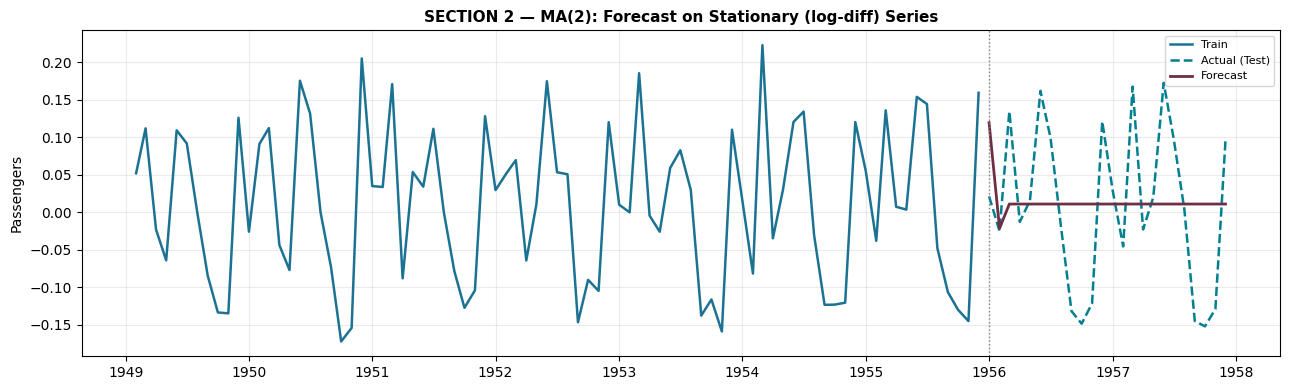

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 : MA (Moving Average Model)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 2 : MA — Moving Average Model")
print("=" * 65)
print("""
  Concept:
    Yₜ = c + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂ + ... + θqεₜ₋q
    → Current value depends on PAST FORECAST ERRORS (residuals), not past Y.
    → Order q : how many past errors to include.
    → Requires STATIONARY series.

  ACF plot: choose q where ACF cuts off (drops inside confidence band).
""")

ma_model = ARIMA(stat_train, order=(0, 0, 2)).fit()
ma_fc    = ma_model.forecast(steps=len(stat_test))
ma_fc.index = stat_test.index

mae, rmse, mape = compute_metrics(stat_test, ma_fc)
print(f"  MA(2) fitted on stationary (log-diff) series")
print(f"  MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE={mape:.2f}%")

fig, ax = plt.subplots(figsize=(13, 4))
plot_forecast(ax, stat_train, stat_test, ma_fc,
              title="SECTION 2 — MA(2): Forecast on Stationary (log-diff) Series",
              fc_color="#6D2E46")
plt.tight_layout()
plt.show()




  SECTION 3 : ARMA — AR + MA Combined

  Concept:
    Yₜ = c + φ₁Yₜ₋₁ + ... + φₚYₜ₋ₚ + εₜ + θ₁εₜ₋₁ + ... + θqεₜ₋q
    → Combines AR (past values) + MA (past errors).
    → ARMA(p, q)  ≡  ARIMA(p, 0, q)   [no differencing needed]
    → STILL requires STATIONARY series.

  When to prefer ARMA over AR or MA alone:
    → When both ACF and PACF tail off gradually (neither cuts off sharply).

  ARMA(2,2)  ≡  ARIMA(2,0,2)  fitted on stationary series
  MAE=0.09088  RMSE=0.10725  MAPE=118.40%
  AIC = -151.93


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


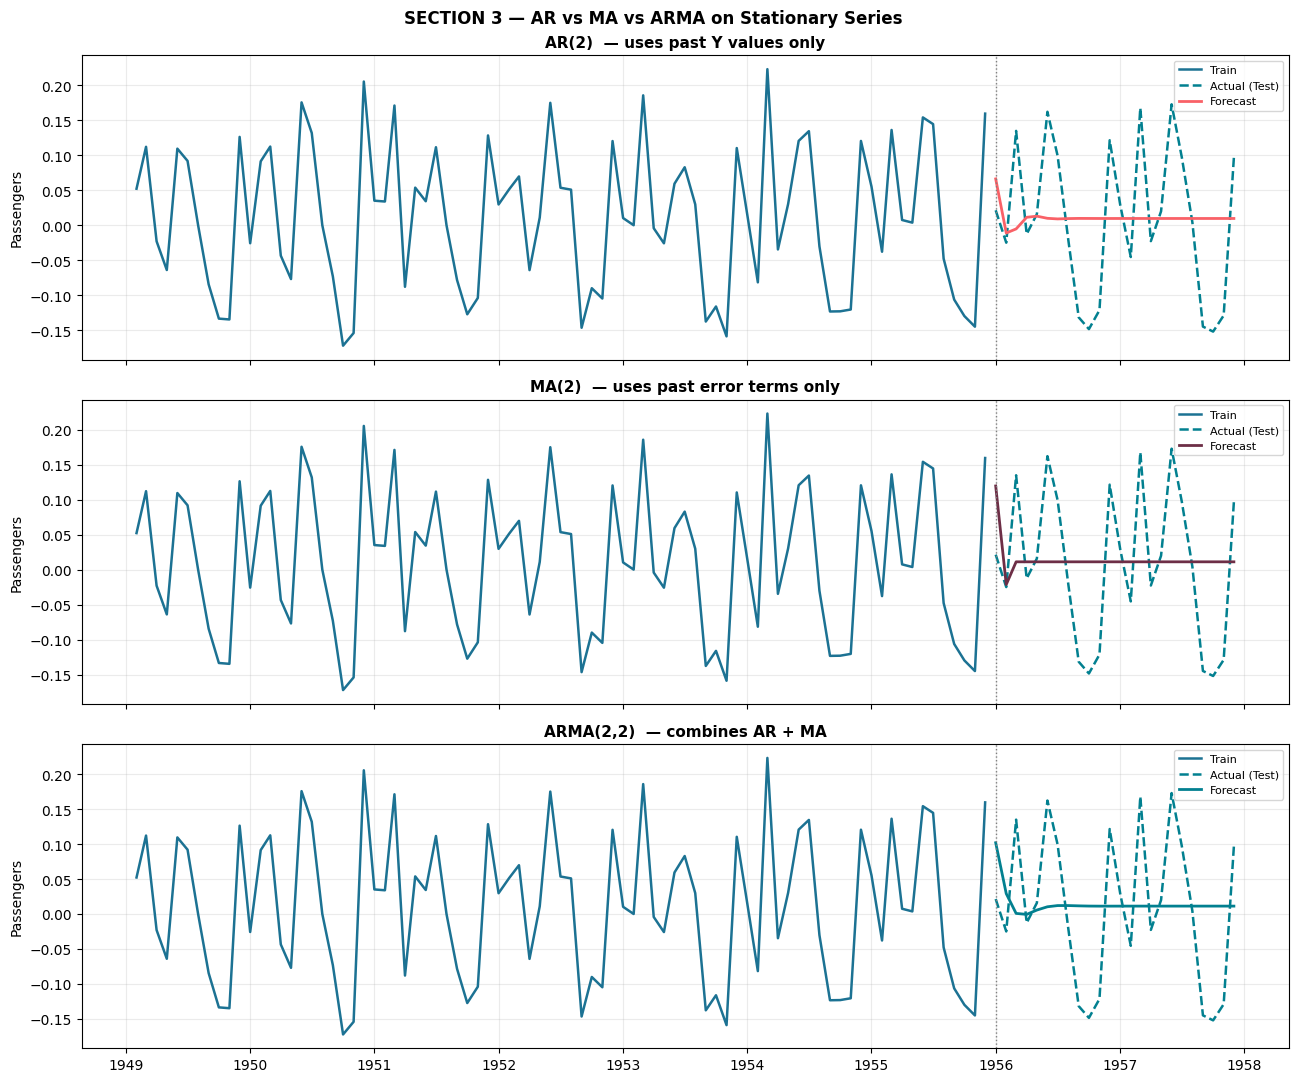

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 : ARMA (AR + MA Combined)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 3 : ARMA — AR + MA Combined")
print("=" * 65)
print("""
  Concept:
    Yₜ = c + φ₁Yₜ₋₁ + ... + φₚYₜ₋ₚ + εₜ + θ₁εₜ₋₁ + ... + θqεₜ₋q
    → Combines AR (past values) + MA (past errors).
    → ARMA(p, q)  ≡  ARIMA(p, 0, q)   [no differencing needed]
    → STILL requires STATIONARY series.

  When to prefer ARMA over AR or MA alone:
    → When both ACF and PACF tail off gradually (neither cuts off sharply).
""")

arma_model = ARIMA(stat_train, order=(2, 0, 2)).fit()
arma_fc    = arma_model.forecast(steps=len(stat_test))
arma_fc.index = stat_test.index

mae, rmse, mape = compute_metrics(stat_test, arma_fc)
print(f"  ARMA(2,2)  ≡  ARIMA(2,0,2)  fitted on stationary series")
print(f"  MAE={mae:.5f}  RMSE={rmse:.5f}  MAPE={mape:.2f}%")
print(f"  AIC = {arma_model.aic:.2f}")

# ── Side-by-side: AR vs MA vs ARMA ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
plot_forecast(axes[0], stat_train, stat_test, ar_fc,
              title="AR(2)  — uses past Y values only", fc_color="#F96167")
plot_forecast(axes[1], stat_train, stat_test, ma_fc,
              title="MA(2)  — uses past error terms only", fc_color="#6D2E46")
plot_forecast(axes[2], stat_train, stat_test, arma_fc,
              title="ARMA(2,2)  — combines AR + MA", fc_color="#028090")
plt.suptitle("SECTION 3 — AR vs MA vs ARMA on Stationary Series",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 4 : ARIMA — ARMA + Differencing

  Concept:
    ARIMA(p, d, q)
      p : AR order  — past values
      d : differencing order  — how many times to difference to reach stationarity
      q : MA order  — past errors

    Key insight:
      ARMA cannot handle non-stationary data (trend).
      ARIMA fixes this by differencing d times INSIDE the model.
      d=0  →  identical to ARMA(p,q)
      d=1  →  models changes  (ΔYₜ = Yₜ - Yₜ₋₁)
      d=2  →  models 2nd-order changes (rare in practice)

  Applied to log(AirPassengers):
    Log-transform first to stabilise variance, then ARIMA handles the trend.
    Remaining seasonality is NOT captured → will be fixed in SARIMA.

  ADF [log(train) — input to ARIMA]  p=0.7542  →  Non-stationary ✗

  ARIMA(2,1,2) on log series → back-transformed to original scale
  MAE=80.37  RMSE=106.69  MAPE=16.71%
  AIC = -186.42
  ⚠  Seasonal pattern NOT captured → residual seasonal error expected


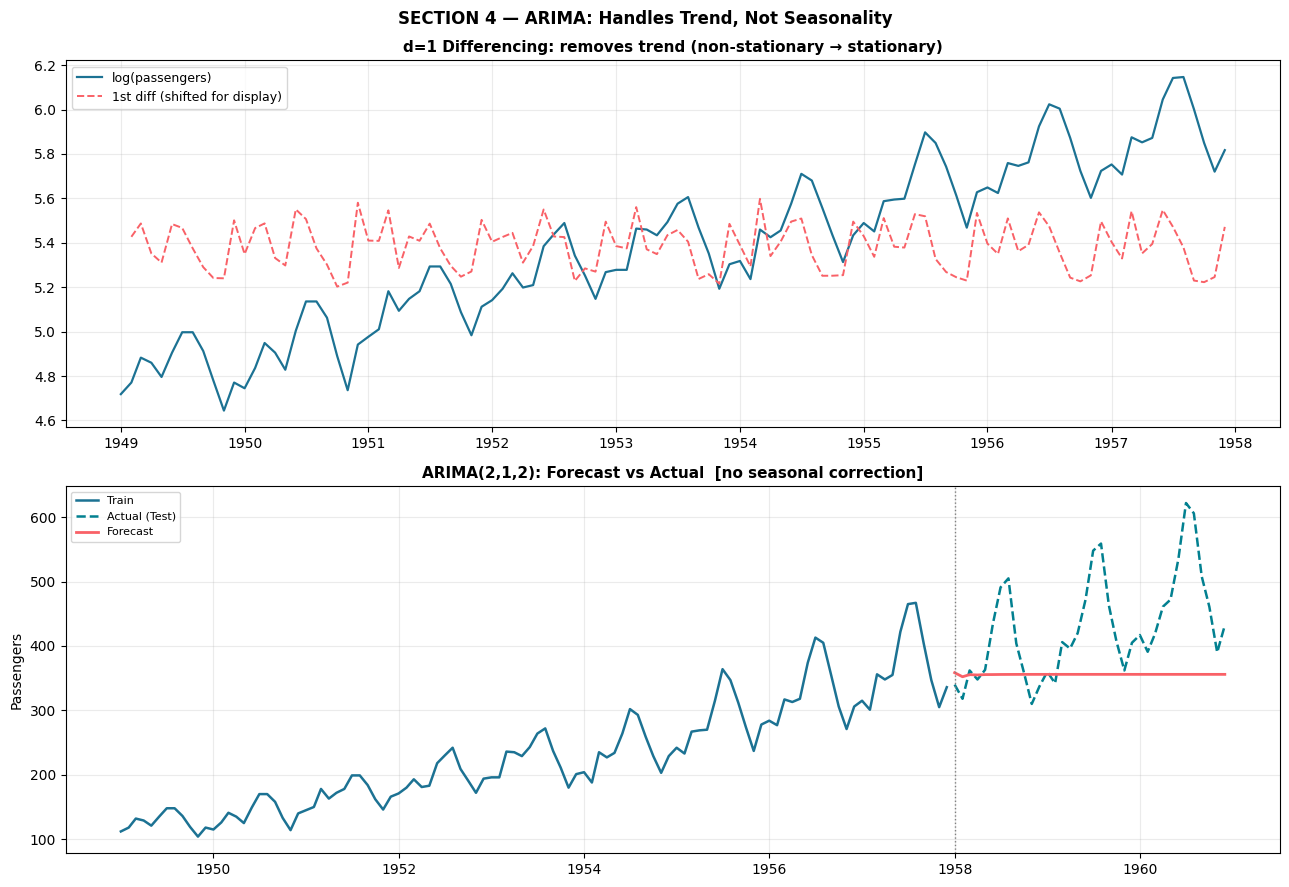

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 : ARIMA (ARMA + Integrated Differencing)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 4 : ARIMA — ARMA + Differencing")
print("=" * 65)
print("""
  Concept:
    ARIMA(p, d, q)
      p : AR order  — past values
      d : differencing order  — how many times to difference to reach stationarity
      q : MA order  — past errors

    Key insight:
      ARMA cannot handle non-stationary data (trend).
      ARIMA fixes this by differencing d times INSIDE the model.
      d=0  →  identical to ARMA(p,q)
      d=1  →  models changes  (ΔYₜ = Yₜ - Yₜ₋₁)
      d=2  →  models 2nd-order changes (rare in practice)

  Applied to log(AirPassengers):
    Log-transform first to stabilise variance, then ARIMA handles the trend.
    Remaining seasonality is NOT captured → will be fixed in SARIMA.
""")

# ADF: confirm log-train is still non-stationary before ARIMA
adf_test(train_log, "log(train) — input to ARIMA")

arima_model = ARIMA(train_log, order=(2, 1, 2)).fit()
arima_fc_log = arima_model.forecast(steps=len(test_log))
arima_fc_log.index = test_log.index
arima_fc = np.exp(arima_fc_log)          # back-transform to original scale

mae, rmse, mape = compute_metrics(test_raw, arima_fc)
print(f"\n  ARIMA(2,1,2) on log series → back-transformed to original scale")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
print(f"  AIC = {arima_model.aic:.2f}")
print("  ⚠  Seasonal pattern NOT captured → residual seasonal error expected")

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# ── Differencing visual ───────────────────────────────────────────────────────
diff_series = train_log.diff(1).dropna()
axes[0].plot(train_log.index, train_log.values, color="#1C7293", lw=1.6,
             label="log(passengers)")
axes[0].plot(diff_series.index, diff_series.values + train_log.mean(),
             color="#F96167", lw=1.4, ls="--", label="1st diff (shifted for display)")
axes[0].set_title("d=1 Differencing: removes trend (non-stationary → stationary)",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)

# ── Forecast vs Actual ────────────────────────────────────────────────────────
plot_forecast(axes[1], train_raw, test_raw, arima_fc.values,
              title="ARIMA(2,1,2): Forecast vs Actual  [no seasonal correction]",
              fc_color="#F96167")

plt.suptitle("SECTION 4 — ARIMA: Handles Trend, Not Seasonality",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()




  SECTION 5 : SARIMA — ARIMA + Seasonal

  Concept:
    SARIMA(p, d, q)(P, D, Q, s)
      p, d, q : non-seasonal AR / differencing / MA  (same as ARIMA)
      P       : seasonal AR order
      D       : seasonal differencing order
      Q       : seasonal MA order
      s       : seasonal period  (12 for monthly data)

    Seasonal differencing:  ΔsYₜ = Yₜ - Yₜ₋ₛ   removes periodic pattern.

  ACF/PACF reading for seasonal orders:
    → Spikes at multiples of s (12, 24, 36) in ACF → seasonal MA term (Q)
    → Spikes at multiples of s in PACF → seasonal AR term (P)

  Chosen model:  SARIMA(1,1,1)(1,1,1,12)



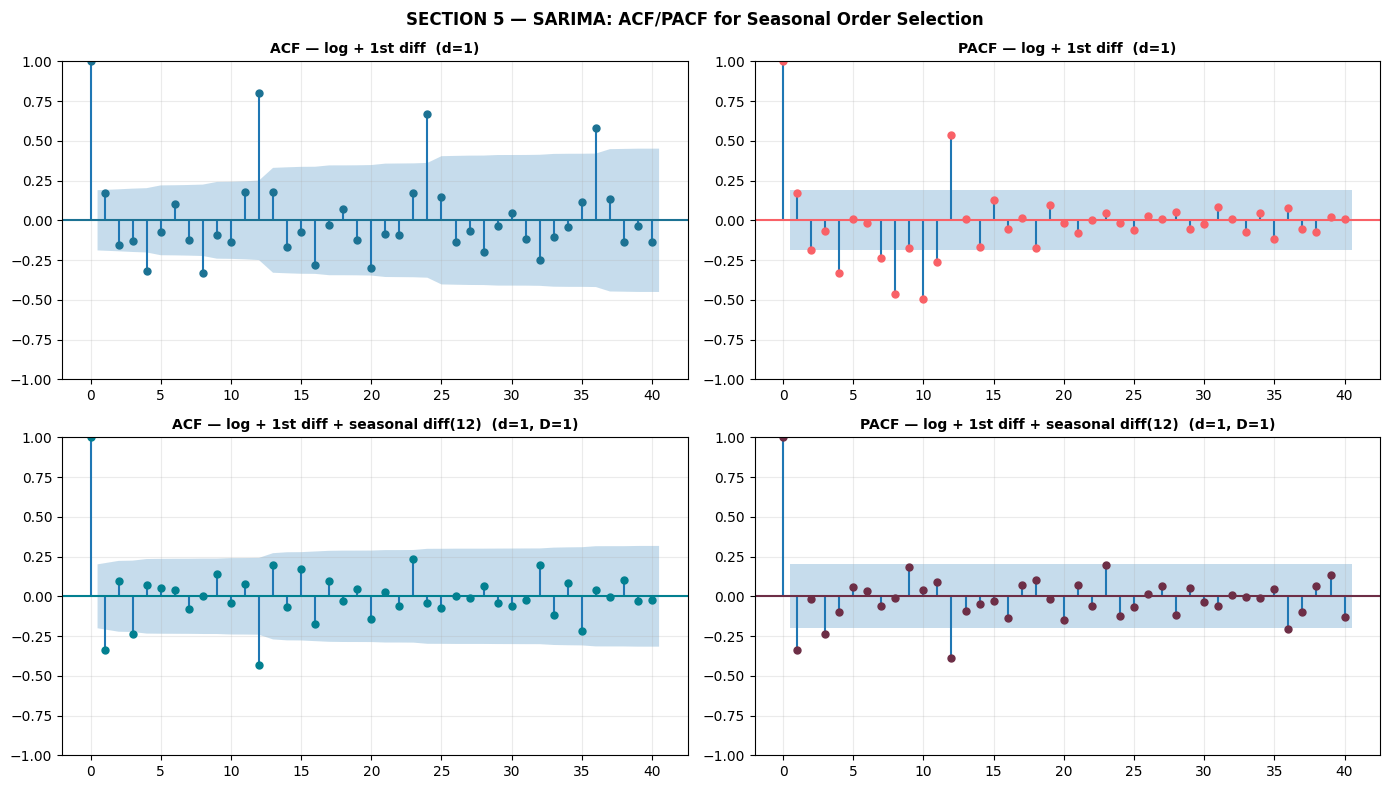

  SARIMA(1,1,1)(1,1,1,12)
  MAE=37.77  RMSE=40.28  MAPE=8.99%
  AIC = -288.00


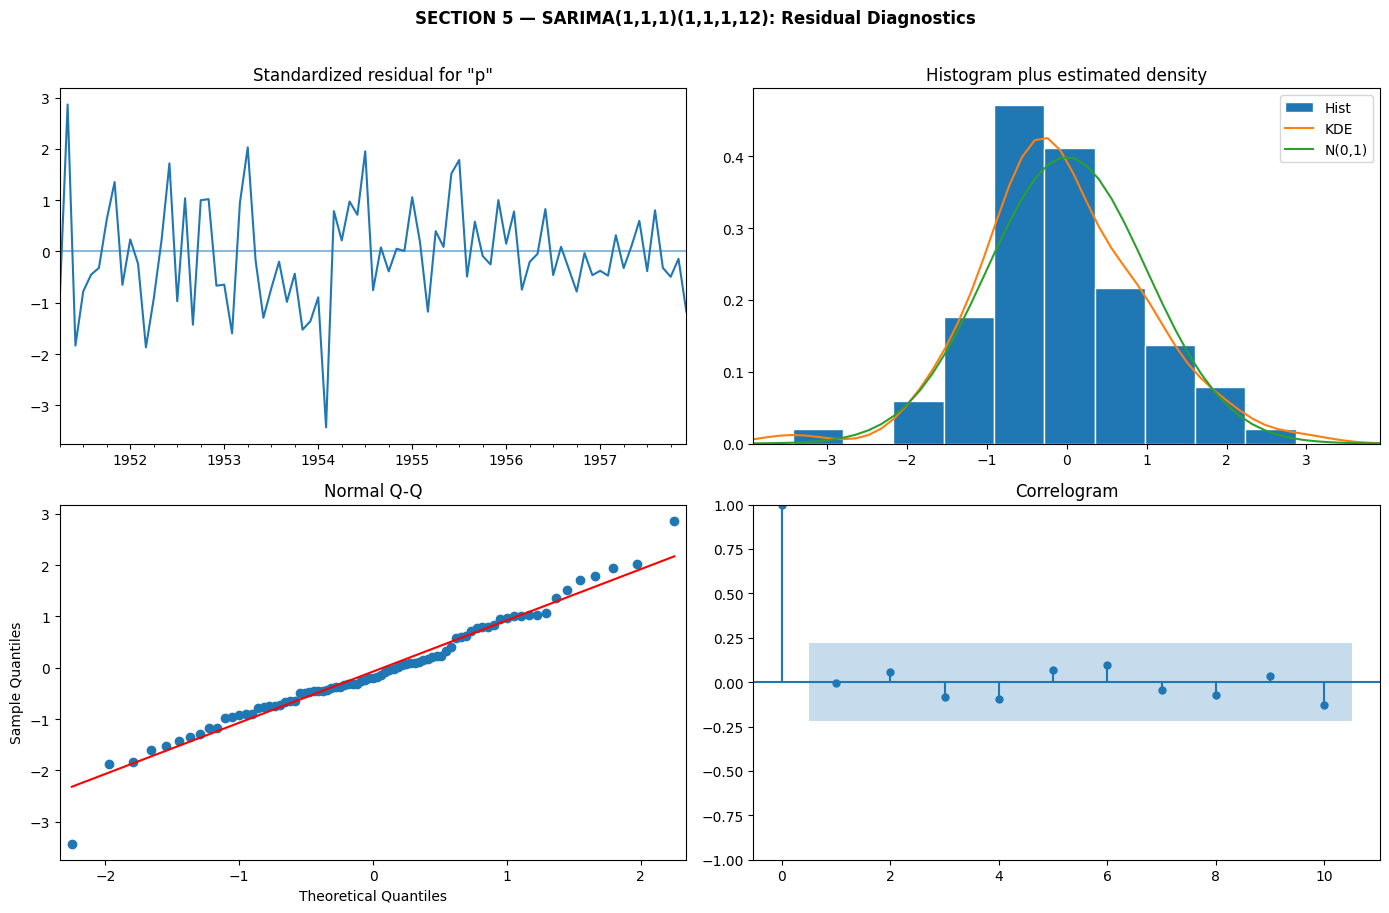

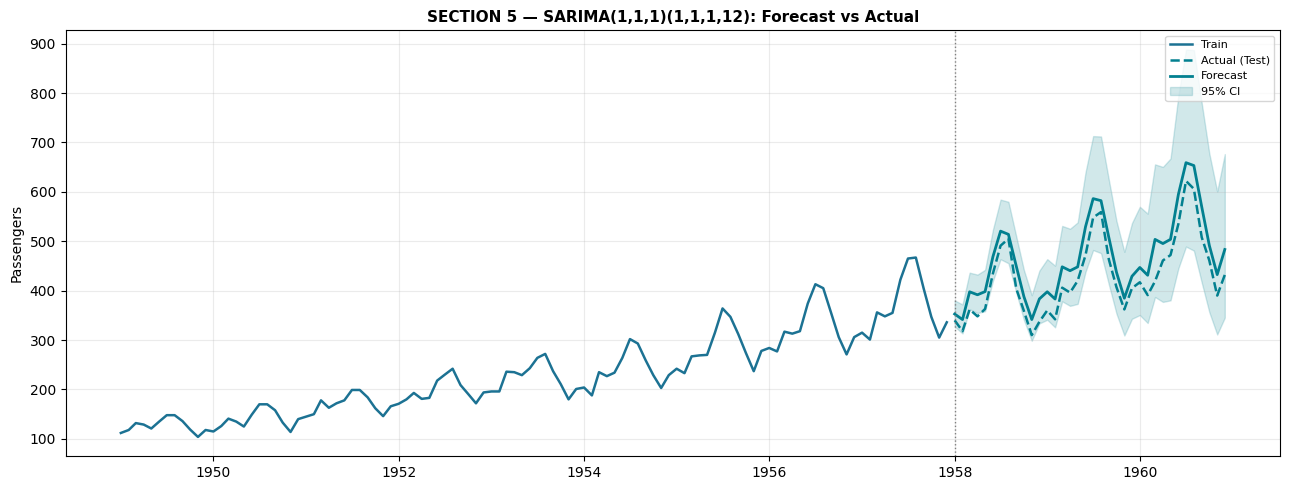

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 : SARIMA (ARIMA + Seasonal Component)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 5 : SARIMA — ARIMA + Seasonal")
print("=" * 65)
print("""
  Concept:
    SARIMA(p, d, q)(P, D, Q, s)
      p, d, q : non-seasonal AR / differencing / MA  (same as ARIMA)
      P       : seasonal AR order
      D       : seasonal differencing order
      Q       : seasonal MA order
      s       : seasonal period  (12 for monthly data)

    Seasonal differencing:  ΔsYₜ = Yₜ - Yₜ₋ₛ   removes periodic pattern.

  ACF/PACF reading for seasonal orders:
    → Spikes at multiples of s (12, 24, 36) in ACF → seasonal MA term (Q)
    → Spikes at multiples of s in PACF → seasonal AR term (P)

  Chosen model:  SARIMA(1,1,1)(1,1,1,12)
""")

# ── ACF/PACF on log + 1st diff + seasonal diff ───────────────────────────────
log_diff1    = train_log.diff(1)
log_diff1_12 = log_diff1.diff(12)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf( log_diff1.dropna(),    lags=40, ax=axes[0,0], color="#1C7293")
axes[0,0].set_title("ACF — log + 1st diff  (d=1)", fontsize=10, fontweight="bold")
plot_pacf(log_diff1.dropna(),    lags=40, ax=axes[0,1], color="#F96167", method="ywm")
axes[0,1].set_title("PACF — log + 1st diff  (d=1)", fontsize=10, fontweight="bold")
plot_acf( log_diff1_12.dropna(), lags=40, ax=axes[1,0], color="#028090")
axes[1,0].set_title("ACF — log + 1st diff + seasonal diff(12)  (d=1, D=1)",
                    fontsize=10, fontweight="bold")
plot_pacf(log_diff1_12.dropna(), lags=40, ax=axes[1,1], color="#6D2E46", method="ywm")
axes[1,1].set_title("PACF — log + 1st diff + seasonal diff(12)  (d=1, D=1)",
                    fontsize=10, fontweight="bold")
for ax in axes.flat: ax.grid(True, alpha=0.25)
plt.suptitle("SECTION 5 — SARIMA: ACF/PACF for Seasonal Order Selection",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Fit SARIMA ────────────────────────────────────────────────────────────────
sarima_model = SARIMAX(train_log,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)

sarima_fc_obj = sarima_model.get_forecast(steps=len(test_log))
sarima_fc_log = sarima_fc_obj.predicted_mean
sarima_ci_log = sarima_fc_obj.conf_int()
sarima_fc     = np.exp(sarima_fc_log)
sarima_ci_lo  = np.exp(sarima_ci_log.iloc[:, 0])
sarima_ci_hi  = np.exp(sarima_ci_log.iloc[:, 1])

mae, rmse, mape = compute_metrics(test_raw, sarima_fc)
print(f"  SARIMA(1,1,1)(1,1,1,12)")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
print(f"  AIC = {sarima_model.aic:.2f}")

# ── Residual diagnostics ──────────────────────────────────────────────────────
fig = sarima_model.plot_diagnostics(figsize=(14, 9))
plt.suptitle("SECTION 5 — SARIMA(1,1,1)(1,1,1,12): Residual Diagnostics",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Forecast plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
plot_forecast(ax, train_raw, test_raw, sarima_fc.values,
              ci_lo=sarima_ci_lo.values, ci_hi=sarima_ci_hi.values,
              title="SECTION 5 — SARIMA(1,1,1)(1,1,1,12): Forecast vs Actual",
              fc_color="#028090")
plt.tight_layout()
plt.show()




  SECTION 6 : Auto ARIMA — Automated Order Selection

  Concept:
    auto_arima() automates the manual steps we did above:
      1. ADF / KPSS test  → determine d and D automatically
      2. Grid search over (p, q, P, Q) ranges
      3. Select best model by AIC (or BIC / HQIC)
      4. Returns a ready-to-use SARIMA model

  Advantages:
    → No manual ACF/PACF reading required
    → Reproducible, fast for production pipelines
    → Stepwise search keeps it efficient

  Key parameters:
    seasonal=True    → enable SARIMA seasonal component
    m=12             → seasonal period (monthly)
    stepwise=True    → faster grid search (recommended)
    information_criterion='aic'  → model selection criterion

  Running auto_arima (this may take ~30 seconds) ...

  Auto ARIMA selected: y
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  108
Model:             SARIM

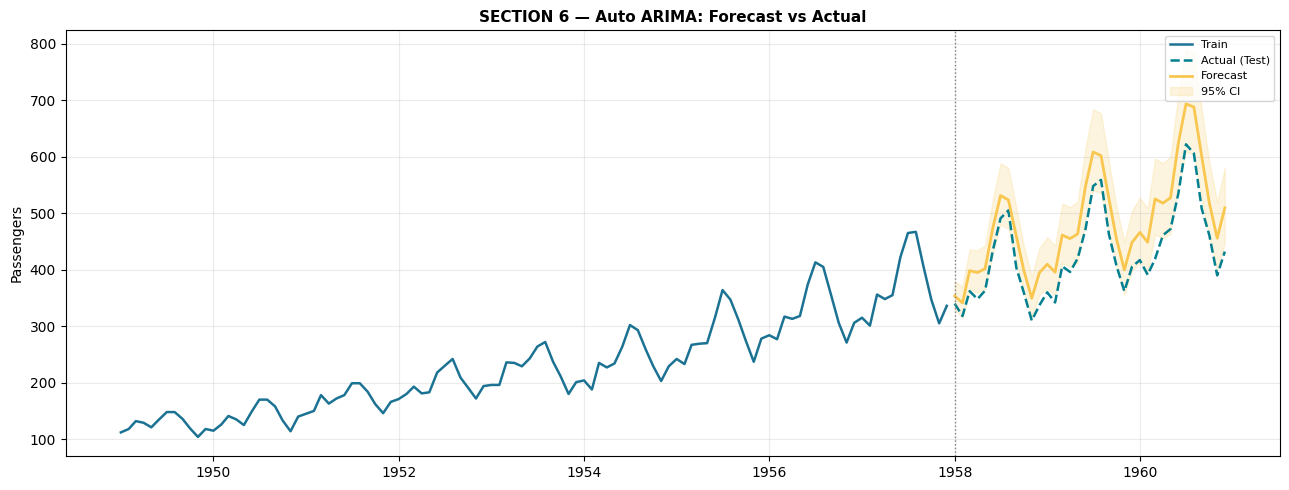


  Refitting Auto ARIMA on full dataset for 1961 forecast ...


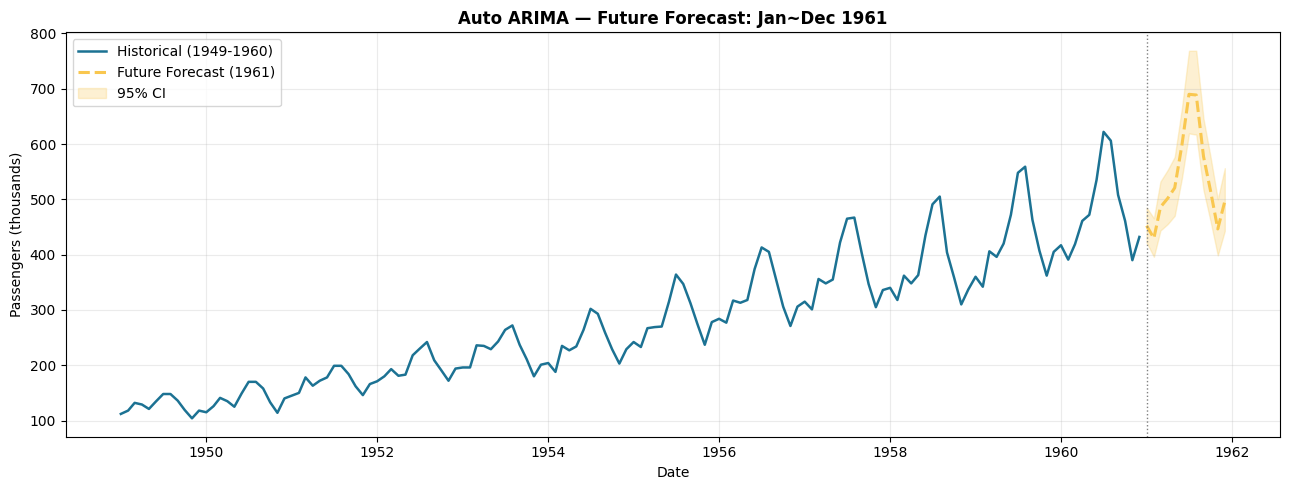


  1961 Monthly Forecast:
    1961-01     452   CI: [422, 485]
    1961-02     430   CI: [396, 466]
    1961-03     486   CI: [444, 532]
    1961-04     502   CI: [455, 553]
    1961-05     521   CI: [470, 577]
    1961-06     599   CI: [539, 665]
    1961-07     690   CI: [619, 769]
    1961-08     689   CI: [617, 769]
    1961-09     578   CI: [517, 646]
    1961-10     516   CI: [461, 577]
    1961-11     446   CI: [399, 500]
    1961-12     496   CI: [443, 556]


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 : Auto ARIMA — Automated Order Selection
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 6 : Auto ARIMA — Automated Order Selection")
print("=" * 65)
print("""
  Concept:
    auto_arima() automates the manual steps we did above:
      1. ADF / KPSS test  → determine d and D automatically
      2. Grid search over (p, q, P, Q) ranges
      3. Select best model by AIC (or BIC / HQIC)
      4. Returns a ready-to-use SARIMA model

  Advantages:
    → No manual ACF/PACF reading required
    → Reproducible, fast for production pipelines
    → Stepwise search keeps it efficient

  Key parameters:
    seasonal=True    → enable SARIMA seasonal component
    m=12             → seasonal period (monthly)
    stepwise=True    → faster grid search (recommended)
    information_criterion='aic'  → model selection criterion
""")

print("  Running auto_arima (this may take ~30 seconds) ...")

auto_model = pm.auto_arima(
    train_log,
    seasonal=True,
    m=12,
    d=None,              # auto-detect d via ADF test
    D=None,              # auto-detect D via seasonal strength
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(f"\n  Auto ARIMA selected: {auto_model.summary().tables[0].data[0][1]}")
print(auto_model.summary())

# ── Forecast ──────────────────────────────────────────────────────────────────
auto_fc_log, auto_ci_log = auto_model.predict(
    n_periods=len(test_log), return_conf_int=True
)
auto_fc    = np.exp(auto_fc_log)
auto_ci_lo = np.exp(auto_ci_log[:, 0])
auto_ci_hi = np.exp(auto_ci_log[:, 1])

auto_fc_series = pd.Series(auto_fc, index=test_raw.index)

mae, rmse, mape = compute_metrics(test_raw, auto_fc)
print(f"\n  Auto ARIMA  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

fig, ax = plt.subplots(figsize=(13, 5))
plot_forecast(ax, train_raw, test_raw, auto_fc,
              ci_lo=auto_ci_lo, ci_hi=auto_ci_hi,
              title=f"SECTION 6 — Auto ARIMA: Forecast vs Actual",
              fc_color="#F9C74F")
plt.tight_layout()
plt.show()

# ── Future forecast: 1961 (12 months beyond data) ─────────────────────────────
print("\n  Refitting Auto ARIMA on full dataset for 1961 forecast ...")

full_auto = pm.auto_arima(
    log_data,
    seasonal=True, m=12,
    d=None, D=None,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

fut_log, fut_ci_log = full_auto.predict(n_periods=12, return_conf_int=True)
fut_fc    = np.exp(fut_log)
fut_ci_lo = np.exp(fut_ci_log[:, 0])
fut_ci_hi = np.exp(fut_ci_log[:, 1])
fut_index = pd.date_range(start="1961-01", periods=12, freq="MS")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(data.index, data.values, color="#1C7293", lw=1.8, label="Historical (1949-1960)")
ax.plot(fut_index, fut_fc, color="#F9C74F", lw=2.2, ls="--", label="Future Forecast (1961)")
ax.fill_between(fut_index, fut_ci_lo, fut_ci_hi,
                color="#F9C74F", alpha=0.25, label="95% CI")
ax.axvline(fut_index[0], color="gray", ls=":", lw=1.0)
ax.set_title("Auto ARIMA — Future Forecast: Jan~Dec 1961",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Passengers (thousands)")
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("\n  1961 Monthly Forecast:")
for d, v, lo, hi in zip(fut_index, fut_fc, fut_ci_lo, fut_ci_hi):
    print(f"    {d.strftime('%Y-%m')}  {v:6.0f}   CI: [{lo:.0f}, {hi:.0f}]")




  SECTION 7 : Model Comparison Summary

  Model                             MAE     RMSE     MAPE
  --------------------------------------------------------
  ARIMA(2,1,2)                    80.37   106.69   16.71%
  SARIMA(1,1,1)(1,1,1,12)         37.77    40.28    8.99%
  Auto ARIMA                      53.97    57.44   12.60%

  Interpretation:
    MAPE < 10%   → Excellent
    MAPE 10~20%  → Good
    MAPE > 20%   → Consider model improvement

  Key Takeaways:
    ┌─────────┬────────────────────────────────────────────────────┐
    │ Model   │ Key Characteristic                                 │
    ├─────────┼────────────────────────────────────────────────────┤
    │ AR(p)   │ Uses own past values; PACF cuts off at lag p       │
    │ MA(q)   │ Uses past errors;     ACF  cuts off at lag q       │
    │ ARMA    │ AR + MA combined; stationary series only           │
    │ ARIMA   │ ARMA + differencing; handles trend                 │
    │ SARIMA  │ ARIMA + seasonal; handles trend +

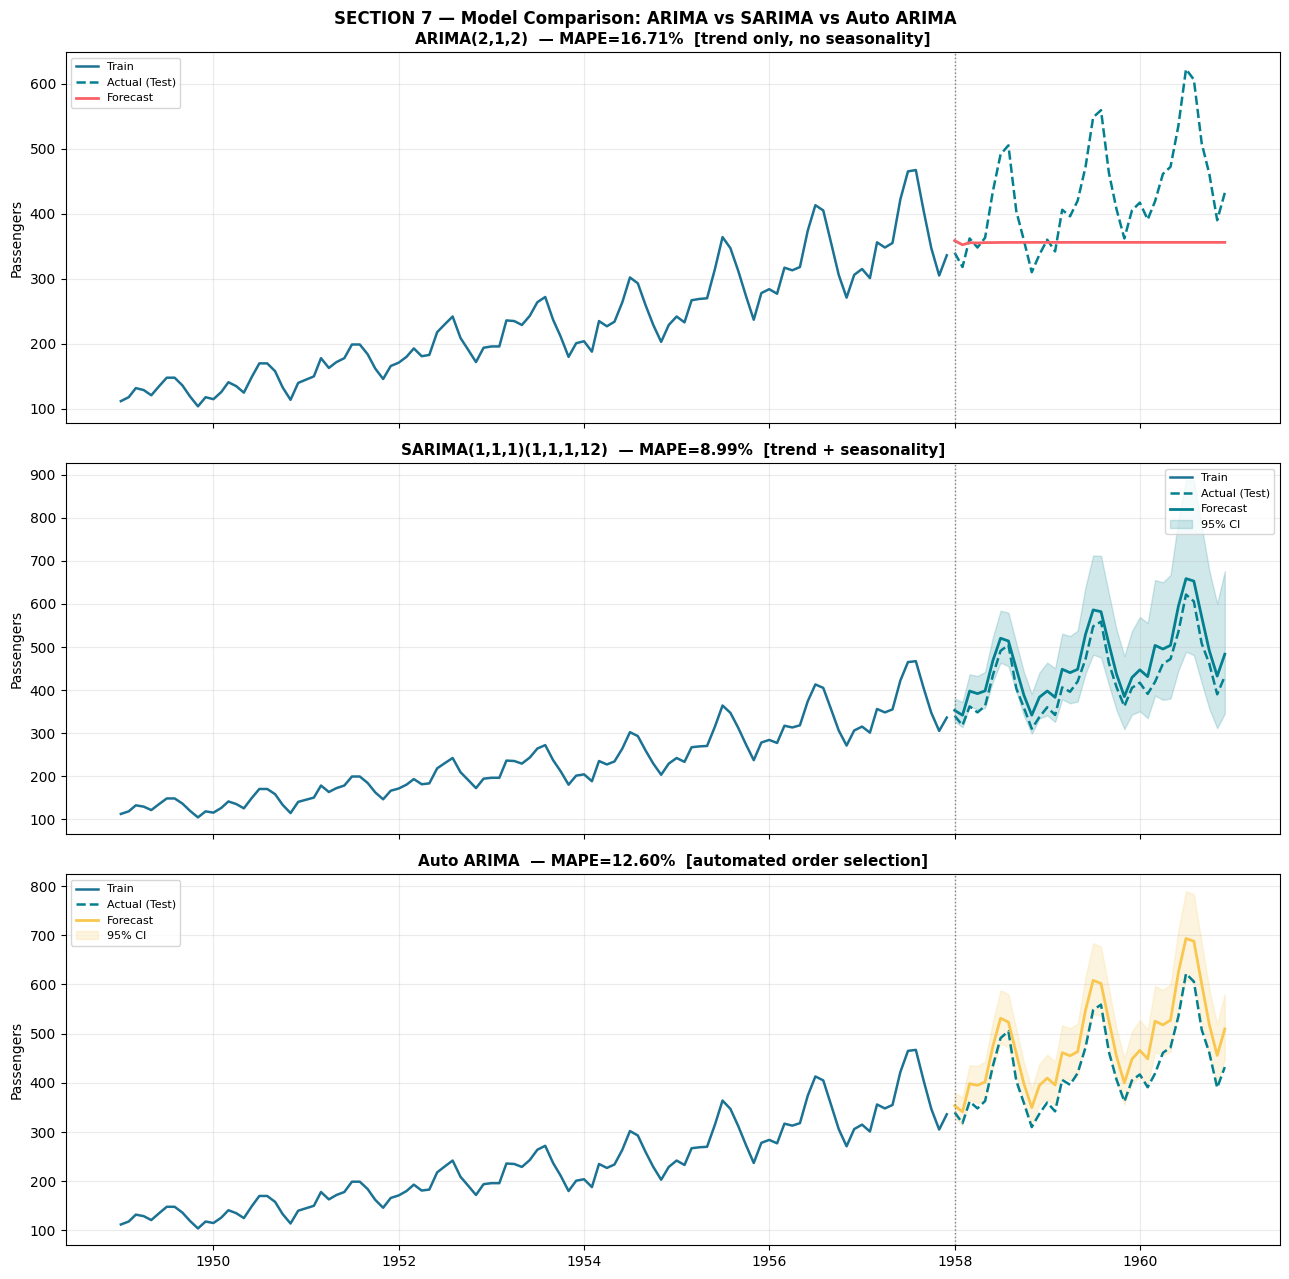


  All sections complete.  Output files saved:
  00_data_overview.png        — raw / log / stationary series
  01_AR_acf_pacf.png          — ACF/PACF for AR order selection
  01_AR_forecast.png          — AR(2) forecast
  02_MA_forecast.png          — MA(2) forecast
  03_AR_MA_ARMA_comparison.png— AR vs MA vs ARMA side-by-side
  04_ARIMA_forecast.png       — ARIMA differencing + forecast
  05_SARIMA_acf_pacf.png      — ACF/PACF with seasonal diff
  05_SARIMA_diagnostics.png   — SARIMA residual diagnostics
  05_SARIMA_forecast.png      — SARIMA forecast with CI
  06_AutoARIMA_forecast.png   — Auto ARIMA test forecast
  06_AutoARIMA_future.png     — Auto ARIMA 1961 future forecast
  07_model_comparison.png     — ARIMA vs SARIMA vs Auto ARIMA


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 : Model Comparison Summary
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 7 : Model Comparison Summary")
print("=" * 65)

# Recompute all metrics on test_raw for fair comparison
#   AR / MA / ARMA operate on log-diff scale → cannot compare directly on raw
#   → compare ARIMA, SARIMA, Auto ARIMA (all back-transformed to raw scale)

metrics = {}

# ARIMA
metrics["ARIMA(2,1,2)"] = compute_metrics(test_raw, arima_fc)

# SARIMA
metrics["SARIMA(1,1,1)(1,1,1,12)"] = compute_metrics(test_raw, sarima_fc)

# Auto ARIMA
metrics["Auto ARIMA"] = compute_metrics(test_raw, auto_fc)

print(f"\n  {'Model':<28}  {'MAE':>7}  {'RMSE':>7}  {'MAPE':>7}")
print("  " + "-" * 56)
for name, (mae, rmse, mape) in metrics.items():
    print(f"  {name:<28}  {mae:7.2f}  {rmse:7.2f}  {mape:6.2f}%")

print("""
  Interpretation:
    MAPE < 10%   → Excellent
    MAPE 10~20%  → Good
    MAPE > 20%   → Consider model improvement

  Key Takeaways:
    ┌─────────┬────────────────────────────────────────────────────┐
    │ Model   │ Key Characteristic                                 │
    ├─────────┼────────────────────────────────────────────────────┤
    │ AR(p)   │ Uses own past values; PACF cuts off at lag p       │
    │ MA(q)   │ Uses past errors;     ACF  cuts off at lag q       │
    │ ARMA    │ AR + MA combined; stationary series only           │
    │ ARIMA   │ ARMA + differencing; handles trend                 │
    │ SARIMA  │ ARIMA + seasonal; handles trend + seasonality      │
    │ Auto    │ Automates d/D detection + (p,q,P,Q) grid search    │
    └─────────┴────────────────────────────────────────────────────┘
""")

# ── Final comparison plot (ARIMA vs SARIMA vs Auto ARIMA) ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

plot_forecast(axes[0], train_raw, test_raw, arima_fc.values,
              title=f"ARIMA(2,1,2)  — MAPE={metrics['ARIMA(2,1,2)'][2]:.2f}%  "
                    "[trend only, no seasonality]",
              fc_color="#F96167")

plot_forecast(axes[1], train_raw, test_raw, sarima_fc.values,
              ci_lo=sarima_ci_lo.values, ci_hi=sarima_ci_hi.values,
              title=f"SARIMA(1,1,1)(1,1,1,12)  — MAPE={metrics['SARIMA(1,1,1)(1,1,1,12)'][2]:.2f}%  "
                    "[trend + seasonality]",
              fc_color="#028090")

plot_forecast(axes[2], train_raw, test_raw, auto_fc,
              ci_lo=auto_ci_lo, ci_hi=auto_ci_hi,
              title=f"Auto ARIMA  — MAPE={metrics['Auto ARIMA'][2]:.2f}%  "
                    "[automated order selection]",
              fc_color="#F9C74F")

plt.suptitle("SECTION 7 — Model Comparison: ARIMA vs SARIMA vs Auto ARIMA",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  All sections complete.  Output files saved:")
print("=" * 65)
files = [
    "00_data_overview.png        — raw / log / stationary series",
    "01_AR_acf_pacf.png          — ACF/PACF for AR order selection",
    "01_AR_forecast.png          — AR(2) forecast",
    "02_MA_forecast.png          — MA(2) forecast",
    "03_AR_MA_ARMA_comparison.png— AR vs MA vs ARMA side-by-side",
    "04_ARIMA_forecast.png       — ARIMA differencing + forecast",
    "05_SARIMA_acf_pacf.png      — ACF/PACF with seasonal diff",
    "05_SARIMA_diagnostics.png   — SARIMA residual diagnostics",
    "05_SARIMA_forecast.png      — SARIMA forecast with CI",
    "06_AutoARIMA_forecast.png   — Auto ARIMA test forecast",
    "06_AutoARIMA_future.png     — Auto ARIMA 1961 future forecast",
    "07_model_comparison.png     — ARIMA vs SARIMA vs Auto ARIMA",
]
for f in files:
    print(f"  {f}")
print("=" * 65)